In [1]:
import os
import copy
import torch
from pathlib import Path
from stMVCL.stMVCL.config import set_arg
from stMVCL.stMVCL.data import *
from stMVCL.stMVCL.utils import *
from stMVCL.stMVCL.stMVCL import *
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score


In [2]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path
# gpu
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
# path
data_root = Path('/home/ZHX/Dataset/Slide-seqV2_MOB')
result_path = "/home/ZHX/code111/GraphST-main/final_result/stMVCL_result/"
#设置参数
opt = set_arg()
arg = opt.parse_args(['--n_domain', '7','--radius', '50','--n_refine','25'])
print(arg)

当前路径： /home/ZHX/code111/GraphST-main/stMVCL/Tutorial
Namespace(epoch=1000, hvg_n=3000, knn=6, latent_dim=64, log_step=10, lr=0.001, n_domain=7, n_refine=25, radius=50, seed=0, temp=0.05, weight_decay=0.0001)


In [3]:
sample_name = 'Slide-seqV2_MOB'
counts_file = os.path.join(data_root, 'Puck_200127_15.digital_expression.txt')
coor_file = os.path.join(data_root, 'Puck_200127_15_bead_locations.csv')
#reading data
counts = pd.read_csv(counts_file, sep='\t', index_col=0)
coor_df = pd.read_csv(coor_file, index_col=0)


In [4]:
coor_df=coor_df.set_index('barcode')
print(counts.shape, coor_df.shape)

(21220, 21724) (21724, 2)


In [5]:
adata = sc.AnnData(counts.T)
adata.var_names_make_unique()
#Add spatial location information
coor_df = coor_df.loc[adata.obs_names, ['xcoord', 'ycoord']]
adata.obsm["spatial"] = coor_df.to_numpy()

sc.pp.calculate_qc_metrics(adata, inplace=True)
print(adata)


AnnData object with n_obs × n_vars = 21724 × 21220
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'


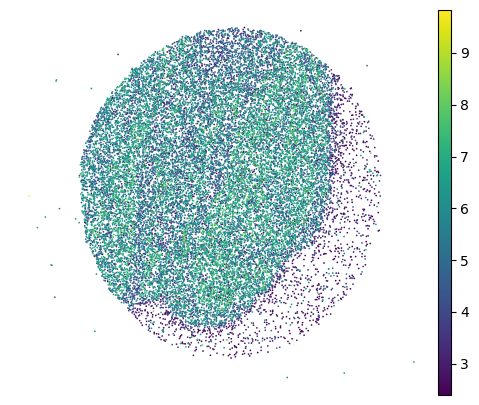

In [6]:
out_path = os.path.join(result_path , sample_name)
# 检查文件夹是否存在，如果不存在则创建文件夹
if not os.path.exists(out_path):
    os.makedirs(out_path)

plt.rcParams["figure.figsize"] = (6,5)
#Original tissue area, some scattered spots
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=6, show=False)
plt.title('')
plt.axis('off')
plt.savefig(os.path.join(out_path,"slide_MOB01.png"))

In [7]:
used_barcode = pd.read_csv(os.path.join(data_root, 'used_barcodes.txt'), sep='\t', header=None)
used_barcode = used_barcode[0]
adata = adata[used_barcode,]
# print(adata)

KeyError: "Values ['Spot_1', 'Spot_10', 'Spot_100', 'Spot_1000', 'Spot_10000', 'Spot_10002', 'Spot_10003', 'Spot_10004', 'Spot_10005', 'Spot_10006', 'Spot_10007', 'Spot_10008', 'Spot_10009', 'Spot_1001', 'Spot_10010', 'Spot_10011', 'Spot_10012', 'Spot_10013', 'Spot_10014', 'Spot_10015', 'Spot_10016', 'Spot_10017', 'Spot_10018', 'Spot_10019', 'Spot_1002', 'Spot_10020', 'Spot_10021', 'Spot_10022', 'Spot_10023', 'Spot_10024', 'Spot_10025', 'Spot_10026', 'Spot_10027', 'Spot_10028', 'Spot_10029', 'Spot_1003', 'Spot_10030', 'Spot_10031', 'Spot_10032', 'Spot_10034', 'Spot_10035', 'Spot_10036', 'Spot_10037', 'Spot_10038', 'Spot_1004', 'Spot_10040', 'Spot_10041', 'Spot_10042', 'Spot_10043', 'Spot_10044', 'Spot_10045', 'Spot_10046', 'Spot_10047', 'Spot_10048', 'Spot_10049', 'Spot_1005', 'Spot_10050', 'Spot_10051', 'Spot_10052', 'Spot_10053', 'Spot_10054', 'Spot_10055', 'Spot_10056', 'Spot_10057', 'Spot_10058', 'Spot_10059', 'Spot_1006', 'Spot_10060', 'Spot_10061', 'Spot_10063', 'Spot_10064', 'Sp

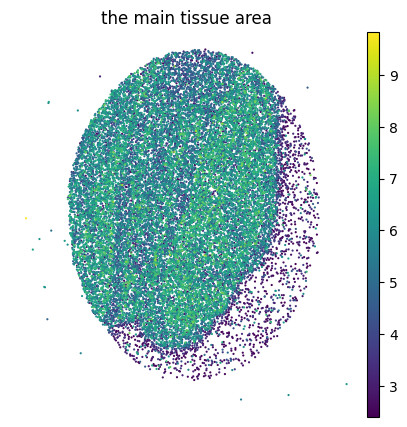

In [8]:
plt.rcParams["figure.figsize"] = (5,5)
#Get rid of the scattered spots and get the main organizational area
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=10, show=False, title='the main tissue area')
plt.axis('off')
plt.savefig(os.path.join(out_path,"slide_MOB02_standard.png"))


In [9]:
sc.pp.filter_genes(adata, min_cells=50)
print('After flitering: ', adata.shape)


After flitering:  (21724, 11801)


In [10]:
#Normalization
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [11]:


# train model
adata = train(adata,arg)
print("Completion of training")

# clustering
adata = mclust_R(adata, arg.n_domain,used_obsm='stMVCL' )
# adata = mclust_R(adata, arg.n_domain,used_obsm='MVInfoNCE' ,refine=True, n_refine=arg.n_refine)

# # filter out NA nodes
# adata = adata[~pd.isnull(adata.obs['Ground Truth'])]
# ARI = adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground Truth'])
# print('ARI = %.4f' %ARI)
# adata.uns['ARI']=ARI

spatial graph(k) completed!
spatial graph(radius) completed!
start construct feature graph
feature graph completed!
Size of Input:  (21724, 3000)
AnnData object with n_obs × n_vars = 21724 × 11801
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh1', 'graph_neigh2', 'adj1', 'adj2', 'feat', 'feat_a', 'f_graph_neigh', 'fadj'


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.76 GiB. GPU 1 has a total capacity of 23.64 GiB of which 778.25 MiB is free. Process 3685099 has 15.00 GiB memory in use. Including non-PyTorch memory, this process has 7.87 GiB memory in use. Of the allocated memory 7.52 GiB is allocated by PyTorch, and 9.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

# plotting predicted labels by UMAP
sc.pp.neighbors(adata, use_rep='MVInfoNCE')
sc.tl.umap(adata)
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.embedding(adata, basis="spatial", color="mclust",s=10,  show=False, title='MVInfoNCE')
plt.axis('off')
plt.savefig(os.path.join(out_path,"{}_umap.png").format(sample_name))